<a href="https://colab.research.google.com/github/EarnGH/ITCS225_Orange/blob/main/os_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimizing Prime Number Detection for Large Numbers
### Goals
This project aims to optimize prime number detection using multithreading and memorization to reduce execution time and improve performance.

### Methods
1. running multithreading
2. parallel processing with a shared memory
3. parallel processing with separate memnory

### Evaluation
1. compare runtime
2. compare efficientcy

**Project Requirements**
* Demonstrate Core OS Concepts 30% <br>
implementing fundemental os functionalities <br>

* Develop Robust and Maintainable Code 20% <br>
write clean code with error handling and easy to read<br>

* Optimize System Performance 15% <br>
analyzing and compare resource before optimization <br>

* Communicate Technical Design <br>
document the project with comments or README <br>
explain reasoning for why choosing this method <br>

* Practical Adaptations 15% <br>
extend the project in ways that connect to real-world scenarios <br>

In [12]:
# import and define global variable
import math
import time
import threading
from multiprocessing import Process, Manager, cpu_count, Array, Pool
import gc

MAX_RANGE = 1_000_000

## finding prime number function

In [13]:
# -------- Prime checker --------
def is_prime(n):
    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

In [14]:
def check_prime_in_range():
  start_time = time.time()
  primes = []
  for n in range(MAX_RANGE):
    if is_prime(n):
      primes.append(n)
  duration = time.time() - start_time

  print(f"\n[NORMAL] Found {len(primes)} primes")
  print(f"[NORMAL] Time: {duration:.10f} seconds")

  return duration

## functions for optimization operation

In [15]:
def simple_multithread():
    primes = []
    lock = threading.Lock()

    def find_primes(start, end):
        local_primes = [n for n in range(start, end) if is_prime(n)]
        with lock:
            primes.extend(local_primes)

    print("\n[THREADING] Starting...")
    start_time = time.time()
    ranges = [(1, int(MAX_RANGE/2)), (int(MAX_RANGE/2), MAX_RANGE)]
    threads = []

    for r in ranges:
        t = threading.Thread(target=find_primes, args=r)
        t.start()
        threads.append(t)

    for t in threads:
        t.join()

    duration = time.time() - start_time
    print(f"[THREADING] Found {len(primes)} primes")
    print(f"[THREADING] Time: {duration:.10f} seconds")
    return duration

In [16]:
def find_primes_list(start, end, shared_flags):
    for i in range(start, end):
        shared_flags[i] = 1 if is_prime(i) else 0

def parallel_shared_memory():
    core_count = cpu_count()
    print("\n[SHARED MEMORY] Starting...")
    print(f"[SHARED MEMORY] CPU cores available: {core_count}")

    start_time = time.time()

    # shared_flags = Array('b', MAX_RANGE, lock=False)
    shared_flags = Array('b', MAX_RANGE, lock=True)

    step = MAX_RANGE // core_count
    ranges = [(i * step, (i + 1) * step if i < core_count - 1 else MAX_RANGE) for i in range(core_count)]

    processes = []

    for r in ranges:
        p = Process(target=find_primes_list, args=(r[0], r[1], shared_flags))
        p.start()
        processes.append(p)

    for p in processes:
        p.join()

    primes = [i for i, flag in enumerate(shared_flags) if flag == 1]

    duration = time.time() - start_time
    print(f"[SHARED MEMORY] Found {len(primes)} primes")
    print(f"[SHARED MEMORY] Time: {duration:.10f} seconds")
    return duration

In [17]:
def find_primes_in_range(start_end): # to not be confused with the find_prime_list above
    start, end = start_end
    return [n for n in range(start, end) if is_prime(n)]

def parallel_pool_memory():
    core_count = cpu_count()
    print("\n[PARALLEL POOL] Starting...")
    print(f"[PARALLEL POOL] CPU cores available: {core_count}")
    start_time = time.time()

    # num_chunks = core_count * 4
    # step = MAX_RANGE // num_chunks
    # ranges = [(i * step + 1, (i + 1) * step + 1) for i in range(num_chunks)]
    step = MAX_RANGE // core_count
    ranges = [(i * step, (i + 1) * step if i < core_count - 1 else MAX_RANGE) for i in range(core_count)]

    with Pool(processes=core_count) as pool:
        results = pool.imap_unordered(find_primes_in_range, ranges)

        all_primes = []
        for sublist in results:
            all_primes.extend(sublist)

    duration = time.time() - start_time
    print(f"[PARALLEL POOL] Found {len(all_primes)} primes")
    print(f"[PARALLEL POOL] Time: {duration:.10f} seconds")
    return duration

## implementing the functions

### for single test

#### no garbage collector

In [18]:
import gc
import time

def run_and_measure(title, func):
    print(f"\n=== {title} ===")
    result = func()
    # gc.collect()
    time.sleep(1)
    return result


# Run all with proper clearing
n_time = run_and_measure("Single Thread", check_prime_in_range)
t_time = run_and_measure("Multithreading", simple_multithread)
m_time = run_and_measure("Parallel Shared Memory", parallel_shared_memory)
mp_time = run_and_measure("Parallel Pool", parallel_pool_memory)

# Comparison
print("\n=== COMPARISON ===")
print(f"Single Threaded Time: {n_time:.5f} seconds")
print(f"Simple Multithreaded Time: {t_time:.5f} seconds")
print(f"Shared Memory Parallel Time: {m_time:.5f} seconds")
print(f"Pool Parallel Time: {mp_time:.5f} seconds")

print(f"Speedup (vs thread): {n_time / t_time:.5f}x")
print(f"Speedup (vs shared): {n_time / m_time:.5f}x")
print(f"Speedup (vs pool): {n_time / mp_time:.5f}x")


=== Single Thread ===

[NORMAL] Found 78498 primes
[NORMAL] Time: 2.6820778847 seconds

=== Multithreading ===

[THREADING] Starting...
[THREADING] Found 78498 primes
[THREADING] Time: 1.7508356571 seconds

=== Parallel Shared Memory ===

[SHARED MEMORY] Starting...
[SHARED MEMORY] CPU cores available: 2
[SHARED MEMORY] Found 78498 primes
[SHARED MEMORY] Time: 3.1535217762 seconds

=== Parallel Pool ===

[PARALLEL POOL] Starting...
[PARALLEL POOL] CPU cores available: 2
[PARALLEL POOL] Found 78498 primes
[PARALLEL POOL] Time: 1.7218558788 seconds

=== COMPARISON ===
Single Threaded Time: 2.68208 seconds
Simple Multithreaded Time: 1.75084 seconds
Shared Memory Parallel Time: 3.15352 seconds
Pool Parallel Time: 1.72186 seconds
Speedup (vs thread): 1.53188x
Speedup (vs shared): 0.85050x
Speedup (vs pool): 1.55767x


#### with garbage collector

In [19]:
import gc
import time

def run_and_measure(title, func):
    print(f"\n=== {title} ===")
    result = func()
    gc.collect()
    time.sleep(1)
    return result


# Run all with proper clearing
n_time = run_and_measure("Single Thread", check_prime_in_range)
t_time = run_and_measure("Multithreading", simple_multithread)
m_time = run_and_measure("Parallel Shared Memory", parallel_shared_memory)
mp_time = run_and_measure("Parallel Pool", parallel_pool_memory)

# Comparison
print("\n=== COMPARISON ===")
print(f"Single Threaded Time: {n_time:.5f} seconds")
print(f"Simple Multithreaded Time: {t_time:.5f} seconds")
print(f"Shared Memory Parallel Time: {m_time:.5f} seconds")
print(f"Pool Parallel Time: {mp_time:.5f} seconds")

print(f"Speedup (vs thread): {n_time / t_time:.5f}x")
print(f"Speedup (vs shared): {n_time / m_time:.5f}x")
print(f"Speedup (vs pool): {n_time / mp_time:.5f}x")


=== Single Thread ===

[NORMAL] Found 78498 primes
[NORMAL] Time: 2.0852127075 seconds

=== Multithreading ===

[THREADING] Starting...
[THREADING] Found 78498 primes
[THREADING] Time: 1.7548780441 seconds

=== Parallel Shared Memory ===

[SHARED MEMORY] Starting...
[SHARED MEMORY] CPU cores available: 2
[SHARED MEMORY] Found 78498 primes
[SHARED MEMORY] Time: 3.0962097645 seconds

=== Parallel Pool ===

[PARALLEL POOL] Starting...
[PARALLEL POOL] CPU cores available: 2
[PARALLEL POOL] Found 78498 primes
[PARALLEL POOL] Time: 2.3414285183 seconds

=== COMPARISON ===
Single Threaded Time: 2.08521 seconds
Simple Multithreaded Time: 1.75488 seconds
Shared Memory Parallel Time: 3.09621 seconds
Pool Parallel Time: 2.34143 seconds
Speedup (vs thread): 1.18824x
Speedup (vs shared): 0.67347x
Speedup (vs pool): 0.89057x


### for 5 times average test

#### no garbage collector

Warming up...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7383079529 seconds

[THREADING] Starting...
[THREADING] Found 78498 primes
[THREADING] Time: 1.7508730888 seconds

[SHARED MEMORY] Starting...
[SHARED MEMORY] CPU cores available: 2
[SHARED MEMORY] Found 78498 primes
[SHARED MEMORY] Time: 3.1247589588 seconds

[PARALLEL POOL] Starting...
[PARALLEL POOL] CPU cores available: 2
[PARALLEL POOL] Found 78498 primes
[PARALLEL POOL] Time: 1.7475287914 seconds

=== Running: Single Thread ===
Trial 1/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 2.0472707748 seconds
Trial 2/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7514960766 seconds
Trial 3/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7697141171 seconds
Trial 4/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 2.6764471531 seconds
Trial 5/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7243566513 seconds
Single Thread Avg: 1.99386s | Std Dev: 0.40323s

=== Running: Multithreading ===
Trial 1/5...

[THREADING] Start

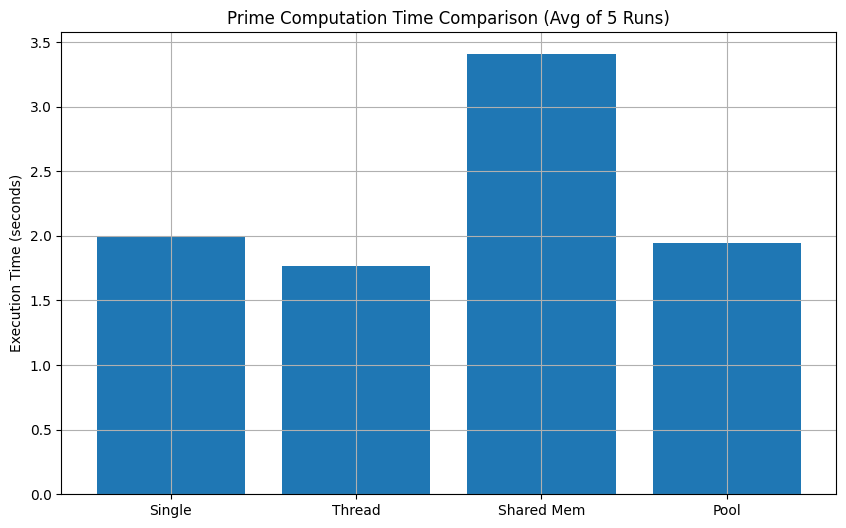

In [20]:
import time
import gc
import statistics
import matplotlib.pyplot as plt

# === Benchmarking Helper ===
def average_runs(name, func, trials=5):
    print(f"\n=== Running: {name} ===")
    durations = []
    for i in range(trials):
        print(f"Trial {i+1}/{trials}...")
        result = func()
        durations.append(result)
        # gc.collect()
        time.sleep(1.5)
    avg = statistics.mean(durations)
    std = statistics.stdev(durations)
    print(f"{name} Avg: {avg:.5f}s | Std Dev: {std:.5f}s")
    return avg

# === Optional Warm-up ===
print("Warming up...")
check_prime_in_range()
simple_multithread()
parallel_shared_memory()
parallel_pool_memory()
gc.collect()
time.sleep(2)

# === Run Benchmarks ===
times = []
labels = ['Single', 'Thread', 'Shared Mem', 'Pool']

n_time = average_runs("Single Thread", check_prime_in_range)
t_time = average_runs("Multithreading", simple_multithread)
m_time = average_runs("Parallel Shared Memory", parallel_shared_memory)
mp_time = average_runs("Parallel Pooled Memory", parallel_pool_memory)

times = [n_time, t_time, m_time, mp_time]

# === Display Comparison ===
print("\n=== FINAL COMPARISON ===")
for label, t in zip(labels, times):
    print(f"{label:<15}: {t:.5f} seconds")

print(f"\nSpeedup (Thread)         : {n_time / t_time:.2f}x")
print(f"Speedup (Shared Memory)  : {n_time / m_time:.2f}x")
print(f"Speedup (Pool)           : {n_time / mp_time:.2f}x")

# === Plot Comparison ===
plt.figure(figsize=(10, 6))
plt.bar(labels, times)
plt.ylabel('Execution Time (seconds)')
plt.title('Prime Computation Time Comparison (Avg of 5 Runs)')
plt.grid(True)
plt.show()


#### with garbage collector

Warming up...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7476377487 seconds

[THREADING] Starting...
[THREADING] Found 78498 primes
[THREADING] Time: 1.7398819923 seconds

[SHARED MEMORY] Starting...
[SHARED MEMORY] CPU cores available: 2
[SHARED MEMORY] Found 78498 primes
[SHARED MEMORY] Time: 3.3273825645 seconds

[PARALLEL POOL] Starting...
[PARALLEL POOL] CPU cores available: 2
[PARALLEL POOL] Found 78498 primes
[PARALLEL POOL] Time: 2.4860355854 seconds

=== Running: Single Thread ===
Trial 1/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7550618649 seconds
Trial 2/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7533996105 seconds
Trial 3/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 2.3803427219 seconds
Trial 4/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7417161465 seconds
Trial 5/5...

[NORMAL] Found 78498 primes
[NORMAL] Time: 1.7247023582 seconds
Single Thread Avg: 1.87104s | Std Dev: 0.28496s

=== Running: Multithreading ===
Trial 1/5...

[THREADING] Start

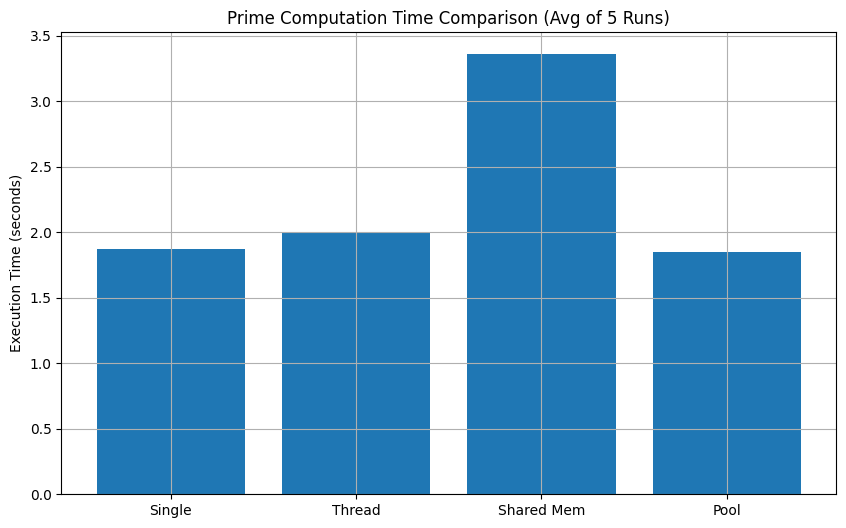

In [21]:
import time
import gc
import statistics
import matplotlib.pyplot as plt

# === Benchmarking Helper ===
def average_runs(name, func, trials=5):
    print(f"\n=== Running: {name} ===")
    durations = []
    for i in range(trials):
        print(f"Trial {i+1}/{trials}...")
        result = func()
        durations.append(result)
        gc.collect()
        time.sleep(1.5)
    avg = statistics.mean(durations)
    std = statistics.stdev(durations)
    print(f"{name} Avg: {avg:.5f}s | Std Dev: {std:.5f}s")
    return avg

# === Optional Warm-up ===
print("Warming up...")
check_prime_in_range()
simple_multithread()
parallel_shared_memory()
parallel_pool_memory()
gc.collect()
time.sleep(2)

# === Run Benchmarks ===
times = []
labels = ['Single', 'Thread', 'Shared Mem', 'Pool']

n_time = average_runs("Single Thread", check_prime_in_range)
t_time = average_runs("Multithreading", simple_multithread)
m_time = average_runs("Parallel Shared Memory", parallel_shared_memory)
mp_time = average_runs("Parallel Pooled Memory", parallel_pool_memory)

times = [n_time, t_time, m_time, mp_time]

# === Display Comparison ===
print("\n=== FINAL COMPARISON ===")
for label, t in zip(labels, times):
    print(f"{label:<15}: {t:.5f} seconds")

print(f"\nSpeedup (Thread)         : {n_time / t_time:.2f}x")
print(f"Speedup (Shared Memory)  : {n_time / m_time:.2f}x")
print(f"Speedup (Pool)           : {n_time / mp_time:.2f}x")

# === Plot Comparison ===
plt.figure(figsize=(10, 6))
plt.bar(labels, times)
plt.ylabel('Execution Time (seconds)')
plt.title('Prime Computation Time Comparison (Avg of 5 Runs)')
plt.grid(True)
plt.show()
